In [1]:
# Import Librabries
import numpy as np
import pandas as pd
import keras
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image

In [2]:
df = pd.read_csv("train.csv")

base_path = "C:\\Users\\daskr\\Downloads\\images"

In [3]:
df

,id,landmark_id
0,17660ef415d37059,1
1,92b6290d571448f6,1
2,cd41bf948edc0340,1
3,fb09f1e98c6d2f70,1
4,25c9dfc7ea69838d,7
...,...,...
1580465,72c3b1c367e3d559,203092
1580466,7a6a2d9ea92684a6,203092
1580467,9401fad4c497e1f9,203092
1580468,aacc960c9a228b5f,203092


In [4]:
samples = 20000

df = df.head(samples)

num_classes = df["landmark_id"].nunique()
num_data = len(df)

print("Classes:", num_classes)
print("Samples:", num_data)

Classes: 1020
Samples: 20000


In [5]:

data = pd.DataFrame(df["landmark_id"].value_counts())

data.reset_index(inplace=True)
data.head()

,landmark_id,count
0,1924,944
1,27,504
2,454,254
3,1346,244
4,1127,201


In [6]:
data.tail()

,landmark_id,count
1015,2495,2
1016,1243,2
1017,1234,2
1018,177,2
1019,1250,2


In [7]:
# remove unwanted column
if 'index' in data.columns:
    data = data.drop(['index'], axis=1)

# check column stats
print(data['landmark_id'].describe())

count    1020.000000
mean     1301.104902
std       740.092621
min         1.000000
25%       684.500000
50%      1282.000000
75%      1955.000000
max      2586.000000
Name: landmark_id, dtype: float64


(array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.,
        0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
        1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.]),
 array([ 0.  ,  0.58,  1.16,  1.74,  2.32,  2.9 ,  3.48,  4.06,  4.64,
         5.22,  5.8 ,  6.38,  6.96,  7.54,  8.12,  8.7 ,  9.28,  9.86,
        10.44, 11.02, 11.6 , 12.18, 12.76, 13.34, 13.92, 14.5 , 15.08,
        15.66, 16.24, 16.82, 17.4 , 17.98, 18.56, 19.14, 19.72, 20.3 ,
        20.88, 21.46, 22.04, 22.62, 23.2 , 23.78, 24.36, 24.94, 25.52,
        26.1 , 26.68, 27.26, 27.84, 28.42, 29.  , 29.58, 30.16, 30.74,
        31.32, 31.9 , 32.48, 33.06, 33.64, 34.22, 34.8 , 35.38, 35.96,
        36.54, 37.12, 37.7 , 38.28, 38.86, 39.44, 40.

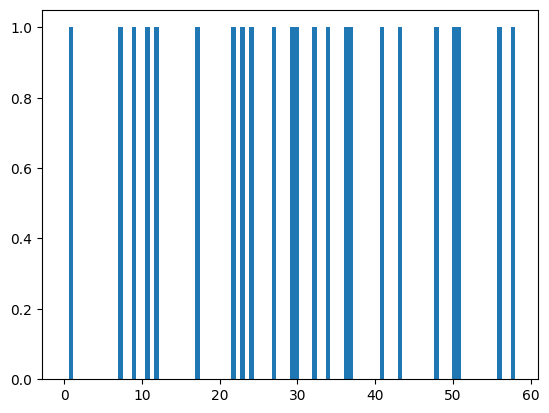

In [8]:
plt.hist(data['landmark_id'], 100, range = (0,58), label = 'test')

In [9]:
data['landmark_id'].between(0,5).sum()


np.int64(1)

In [10]:
data['landmark_id'].between(5,10).sum()


np.int64(2)

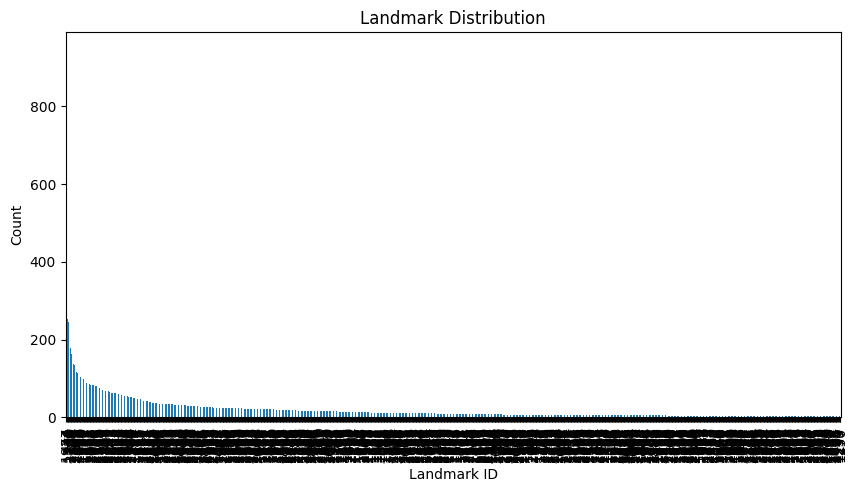

In [11]:

df["landmark_id"].value_counts().plot(kind='bar', figsize=(10,5))

plt.title("Landmark Distribution")
plt.xlabel("Landmark ID")
plt.ylabel("Count")

plt.show()

In [12]:

# Training of Model
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [13]:
df.head()

,id,landmark_id
0,17660ef415d37059,1
1,92b6290d571448f6,1
2,cd41bf948edc0340,1
3,fb09f1e98c6d2f70,1
4,25c9dfc7ea69838d,7


In [14]:
from sklearn.preprocessing import LabelEncoder

lencoder = LabelEncoder()

df = df.copy() 

df.loc[:, 'landmark_id'] = lencoder.fit_transform(df['landmark_id'])

In [15]:
def get_image_from_number(num):
    fname, label = df.loc[num, :]
    
    fname = str(fname) + ".jpg"
    
    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]

    path = os.path.join(base_path, f1, f2, f3, fname)

    img = cv2.imread(path)

    if img is None:
        print("Missing:", path)
        return None, None

    return img, label

4 Sample images from random classes


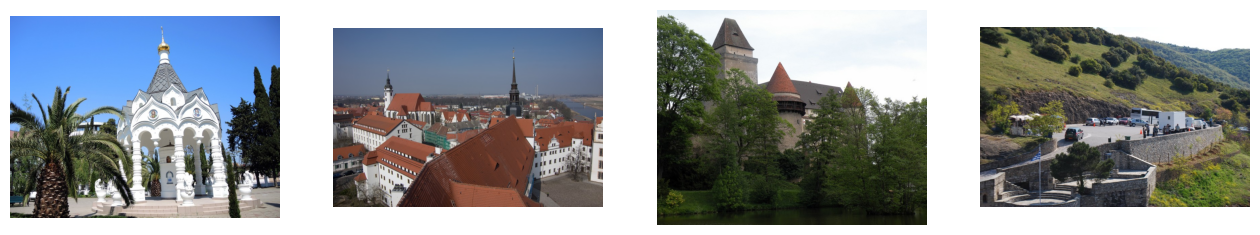

In [16]:
print("4 Sample images from random classes")

fig = plt.figure(figsize=(16,16))

count = 0
i = 1

while count < 4:
    idx = random.randint(0, len(df)-1)
    img_id = str(df.iloc[idx]['id'])

    folder = os.path.join(base_path, img_id[0], img_id[1], img_id[2])
    path = os.path.join(folder, img_id + ".jpg")

    if not os.path.exists(path):
        continue

    img = np.array(Image.open(path))

    fig.add_subplot(1,4,i)
    plt.imshow(img)
    plt.axis('off')

    i += 1
    count += 1

plt.show()

In [17]:
import tensorflow as tf

from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout

In [18]:
from tensorflow.keras.applications import VGG19

source_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [19]:
model = Sequential()

# Add VGG layers
for layer in source_model.layers:
    model.add(layer)

# Freeze base layers
for layer in model.layers:
    layer.trainable = False

# Add custom layers
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 33,493,564 (127.77 MB)

 Trainable params: 13,419,004 (51.19 MB)

 Non-trainable params: 20,074,560 (76.58 MB)

In [21]:
import tensorflow as tf

learning_rate = 0.0001   # 🔥 add this

optim1 = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

model.compile(
    optimizer=optim1,
    loss="categorical_crossentropy",   # or your loss_function
    metrics=["accuracy"]
)

In [22]:
def image_reshape(im, target_size):
    return cv2.resize(im, target_size)

In [23]:
df = df.sample(3000, random_state=42)

In [24]:
def get_image_from_number(num, dataframe):
    fname, label = dataframe.iloc[num, :]

    fname = str(fname) + ".jpg"

    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]

    path = os.path.join(base_path, f1, f2, f3, fname)

    img = cv2.imread(path)

    if img is None:
        return None, None

    return img, label

In [27]:
from tensorflow.keras.utils import to_categorical

def encode_label(lbl):
    return to_categorical(lbl)

In [29]:
batch_size = 16
epochs = 1

# Reduce dataset (important for laptop)
df = df.sample(3000, random_state=42).reset_index(drop=True)

# Split
train, val = np.split(df.sample(frac=1, random_state=42), [int(0.8*len(df))])

for e in range(epochs):
    print("Epoch:", e+1)

    # Shuffle training data
    train = train.sample(frac=1).reset_index(drop=True)

    for it in range(int(np.ceil(len(train)/batch_size))):
        X_train, y_train = get_batch(train, it*batch_size, batch_size)

        # Skip empty batch
        if len(X_train) == 0:
            continue

        model.train_on_batch(X_train, y_train)

    #  Validation
    X_val, y_val = get_batch(val, 0, len(val))

    if len(X_val) > 0:
        loss, acc = model.evaluate(X_val, y_val, verbose=0)
        print("Validation Accuracy:", acc)

# Save model
model.save("Model.keras")

print("Training completed ")

Epoch: 1


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(1, 927), output.shape=(1, 1020)

In [30]:
def get_batch(dataframe, start, batch_size):
    image_array = []
    label_array = []

    end = min(start + batch_size, len(dataframe))

    for idx in range(start, end):
        img, label = get_image_from_number(idx, dataframe)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224)) / 255.0

        image_array.append(img)
        label_array.append(label)

    if len(image_array) == 0:
        return np.array([]), np.array([])

    label_array = encode_label(label_array)

    return np.array(image_array), np.array(label_array)

In [31]:
print("Showing predictions")

fig = plt.figure(figsize=(10,5))

source_list = good_preds if len(good_preds) > 0 else bad_preds

for i in range(min(4, len(source_list))):
    n = source_list[i][0]

    img, label = get_image_from_number(n, val)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig.add_subplot(1,4,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

Showing predictions


<Figure size 1000x500 with 0 Axes>